# Partitioning Method Comparison

This notebook inspects the metaparameter study results produced by `src/mqt/ionshuttler/multi_shuttler/main2.py`. It normalizes every entry stored in `outputs/simulation_results*.h5` and produces comparison plots between each partitioning strategy across all swept parameters (number of processing zones, ions per zone, grid size, MZ trap size, DAG compilation, and slice-plan enforcement).

Steps covered below:

1. Locate and select the HDF5 run summary you want to analyze.
2. Load it into a tidy pandas DataFrame with normalized partitioning metadata.
3. Use the helper utilities to summarize, visualize, and compare partitioning methods.


## Prerequisites

- Make sure the metaparameter study has been executed so that one or more `simulation_results*.h5` files exist inside `outputs/` (and optionally `outputs/archive/`).
- The notebook relies on `pandas`, `numpy`, `matplotlib`, and `h5py`. If any import fails, install the missing package inside the same environment that launches Jupyter (the project's virtual environment already contains these dependencies).
- Set `RESULTS_FILE` in the next section if you prefer a different results file than the default shown in the table.


In [157]:
from __future__ import annotations

import ast
import json
import os
from datetime import datetime
from pathlib import Path
from typing import Any

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

plt.style.use("tableau-colorblind10")


In [158]:
def find_project_root(marker: str = "pyproject.toml") -> Path:
    current = Path.cwd()
    for candidate in [current, *current.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not locate {marker} starting from {current}.")

PROJECT_ROOT = find_project_root()
OUTPUT_DIRS = [PROJECT_ROOT / "outputs"]

def list_result_files(pattern: str = "simulation_results*.h5") -> list[Path]:
    files: list[Path] = []
    for directory in OUTPUT_DIRS:
        if directory.exists():
            files.extend(sorted(directory.glob(pattern)))
    files.sort(key=lambda path: path.stat().st_mtime)
    return files

available_result_files = list_result_files()
file_records = []
for path in available_result_files:
    stat = path.stat()
    file_records.append(
        {
            "file": str(path.relative_to(PROJECT_ROOT)),
            "modified": datetime.fromtimestamp(stat.st_mtime).isoformat(timespec="seconds"),
            "size_kb": round(stat.st_size / 1024, 1),
        }
    )

files_df = pd.DataFrame(file_records)
display(files_df if not files_df.empty else "No simulation_results*.h5 files found yet.")

if available_result_files:
    print("Defaulting to the most recently modified file shown above.")
    RESULTS_FILE = available_result_files[-1]
else:
    RESULTS_FILE = PROJECT_ROOT / "outputs" / "simulation_results.h5"

print(f"RESULTS_FILE = {RESULTS_FILE}")
print("Set RESULTS_FILE manually if you prefer a different file.")


,file,modified,size_kb
0,outputs/simulation_results_random_nativegates_...,2025-11-20T16:53:07,2230.0
1,outputs/simulation_results_grover-noancilla_in...,2025-11-21T12:38:29,93.0
2,outputs/simulation_results_random_indep_tket.h5,2025-11-21T13:02:10,53.9
3,outputs/simulation_results_qpeexact_indep_tket.h5,2025-11-21T14:40:05,885.5
4,outputs/simulation_results_generated.h5,2025-11-21T14:58:29,242.5


Defaulting to the most recently modified file shown above.
RESULTS_FILE = /home/linus/code/ionshuttler/outputs/simulation_results_generated.h5
Set RESULTS_FILE manually if you prefer a different file.


## Data loading helpers

The following utilities normalize the HDF5 attributes into plain Python objects, decode the partitioning metadata, and create a tidy DataFrame that includes useful derived columns (such as `total_ions` or a human-readable `grid_label`).


In [159]:
COMPARISON_KEYS = ["grid_size", "mz_trap_size", "num_pzs", "ions_per_pz", "use_dag", "enforce_slice_plan", "algo_sigma", "algo_lookahead_weight_factor", "algo_balance_penalty"]

def normalize_attr(value: Any) -> Any:
    if isinstance(value, bytes):
        return value.decode()
    if isinstance(value, np.generic):
        return value.item()
    return value

def parse_partitioning_attr(raw_value: Any) -> dict[str, Any]:
    normalized = normalize_attr(raw_value)
    if normalized is None:
        return {"method": "none", "label": "none", "params": {}, "raw": normalized}
    if isinstance(normalized, str):
        text = normalized.strip()
        if text.lower() in {"none", "null", ""}:
            return {"method": "none", "label": "none", "params": {}, "raw": normalized}
        try:
            parsed = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            parsed = text
    else:
        parsed = normalized

    if isinstance(parsed, dict):
        method = parsed.get("name") or parsed.get("method") or "custom"
        params = parsed.get("params", {})
    else:
        method = str(parsed)
        params = {}

    label = method
    if params:
        param_str = ", ".join(f"{key}={params[key]}" for key in sorted(params))
        label = f"{method} ({param_str})"

    return {"method": method, "label": label, "params": params, "raw": normalized}

def load_results(file_path: Path) -> tuple[pd.DataFrame, dict[str, Any]]:
    path = Path(file_path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"{path} does not exist.")
    records: list[dict[str, Any]] = []
    with h5py.File(path, "r") as handle:
        if "results" not in handle:
            raise KeyError(f"No 'results' group found in {path}.")
        file_metadata = {key: normalize_attr(value) for key, value in handle.attrs.items()}
        for run_name, run_group in handle["results"].items():
            attrs = {key: normalize_attr(value) for key, value in run_group.attrs.items()}
            entry: dict[str, Any] = {"run_name": run_name, **attrs}
            partition_info = parse_partitioning_attr(entry.pop("partitioning_algorithm", "none"))
            entry["partition_method"] = partition_info["method"]
            entry["partition_variant"] = partition_info["label"]
            entry["partition_params"] = partition_info["params"]
            entry["source_file"] = str(path.relative_to(PROJECT_ROOT))
            entry["total_ions"] = entry["num_pzs"] * entry["ions_per_pz"]
            entry["grid_label"] = f"{entry['grid_size']}x{entry['grid_size']}"
            records.append(entry)

    df = pd.DataFrame(records).sort_values("run_name").reset_index(drop=True)
    bool_columns = ["success", "use_dag", "enforce_slice_plan"]
    for column in bool_columns:
        if column in df.columns:
            df[column] = df[column].astype(bool)
    return df, file_metadata


In [160]:
results_df, file_metadata = load_results(RESULTS_FILE)
print("File metadata:")
print(json.dumps(file_metadata, indent=2))
print(f"Loaded {len(results_df)} runs from {RESULTS_FILE}.")
results_df.head()


File metadata:
{
  "algorithm_name": "generated",
  "base_num_ions": 15,
  "created_at": "2025-11-21T14:55:10.089665",
  "seed": 0
}
Loaded 135 runs from /home/linus/code/ionshuttler/outputs/simulation_results_generated.h5.


,run_name,algo_balance_penalty,algo_sigma,cpu_time_seconds,enforce_slice_plan,final_timesteps,grid_size,ions_per_pz,mz_trap_size,num_ions,num_pzs,success,use_dag,partition_method,partition_variant,partition_params,source_file,total_ions,grid_label,error_message
0,run_0000,1.75,1.5,0.117024,False,80.0,4,3,1,6,2,True,False,fgp_tabu,fgp_tabu,{},outputs/simulation_results_generated.h5,6,4x4,NaN
1,run_0001,1.75,1.5,0.098280,False,83.0,4,4,1,6,2,True,False,fgp_tabu,fgp_tabu,{},outputs/simulation_results_generated.h5,8,4x4,NaN
2,run_0002,1.75,1.5,0.107986,False,82.0,4,5,1,6,2,True,False,fgp_tabu,fgp_tabu,{},outputs/simulation_results_generated.h5,10,4x4,NaN
3,run_0003,1.75,1.5,0.120173,False,84.0,4,3,1,6,3,True,False,fgp_tabu,fgp_tabu,{},outputs/simulation_results_generated.h5,9,4x4,NaN
4,run_0004,1.75,1.5,0.104050,False,83.0,4,4,1,6,3,True,False,fgp_tabu,fgp_tabu,{},outputs/simulation_results_generated.h5,12,4x4,NaN


In [161]:
success_df = results_df[results_df["success"]].copy()
print(f"{len(success_df)} successful runs ({len(results_df) - len(success_df)} failures dropped).")
print("Runs per partitioning method:")
display(success_df["partition_method"].value_counts().to_frame(name="count"))
success_df.head()




119 successful runs (16 failures dropped).
Runs per partitioning method:


,count
partition_method,
fgp_tabu,74
none,45


,run_name,algo_balance_penalty,algo_sigma,cpu_time_seconds,enforce_slice_plan,final_timesteps,grid_size,ions_per_pz,mz_trap_size,num_ions,num_pzs,success,use_dag,partition_method,partition_variant,partition_params,source_file,total_ions,grid_label,error_message
0,run_0000,1.75,1.5,0.117024,False,80.0,4,3,1,6,2,True,False,fgp_tabu,fgp_tabu,{},outputs/simulation_results_generated.h5,6,4x4,NaN
1,run_0001,1.75,1.5,0.098280,False,83.0,4,4,1,6,2,True,False,fgp_tabu,fgp_tabu,{},outputs/simulation_results_generated.h5,8,4x4,NaN
2,run_0002,1.75,1.5,0.107986,False,82.0,4,5,1,6,2,True,False,fgp_tabu,fgp_tabu,{},outputs/simulation_results_generated.h5,10,4x4,NaN
3,run_0003,1.75,1.5,0.120173,False,84.0,4,3,1,6,3,True,False,fgp_tabu,fgp_tabu,{},outputs/simulation_results_generated.h5,9,4x4,NaN
4,run_0004,1.75,1.5,0.104050,False,83.0,4,4,1,6,3,True,False,fgp_tabu,fgp_tabu,{},outputs/simulation_results_generated.h5,12,4x4,NaN


## Filtering, summaries, and plotting

Use the helpers below to subset the data (`apply_filters`), compute descriptive statistics (`summarize_metric`), and render comparison plots (`plot_metric_by_param`). Provide filters such as `{"use_dag": True, "ions_per_pz": 3}` to focus on a particular slice.


In [179]:
from collections.abc import Mapping

def apply_filters(df: pd.DataFrame, filters: Mapping[str, Any] | None = None) -> pd.DataFrame:
    if not filters:
        return df
    filtered = df.copy()
    for key, value in filters.items():
        if key not in filtered.columns:
            continue
        if isinstance(value, (list, tuple, set)):
            mask = filtered[key].isin(value) | filtered[key].isna()
            filtered = filtered[mask]
        else:
            mask = (filtered[key] == value) | filtered[key].isna()
            filtered = filtered[mask]
    return filtered

def summarize_metric(
    df: pd.DataFrame,
    metric: str,
    varying_param: str,
    method_col: str = "partition_method",
    agg: str = "median",
    filters: Mapping[str, Any] | None = None,
) -> pd.DataFrame:
    filtered = apply_filters(df, filters)
    if filtered.empty:
        return pd.DataFrame()
    grouped = filtered.groupby([varying_param, method_col])[metric]
    summary = grouped.agg(["count", "mean", "median", "min", "max", "std"]).reset_index()
    if agg not in summary.columns:
        raise ValueError(f"Unsupported aggregation '{agg}'. Available columns: {summary.columns.tolist()}.")
    return summary

def sort_param_values(values: pd.Series) -> list[Any]:
    uniques = pd.unique(values)
    try:
        return sorted(uniques)
    except TypeError:
        return sorted(uniques, key=lambda item: str(item))

def plot_metric_by_param(
    df: pd.DataFrame,
    metric: str,
    varying_param: str,
    method_col: str = "partition_method",
    agg: str = "mean",
    plot_std: bool = True,
    secondary_group: str | None = None,
    filters: Mapping[str, Any] | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    summary = summarize_metric(df, metric, varying_param, method_col, agg, filters)
    if summary.empty:
        return None
    
    # If secondary_group is specified, we need to get the data from the original df
    if secondary_group:
        filtered = apply_filters(df, filters)
        if filtered.empty:
            return None
        # Group by varying_param, method_col, and secondary_group
        grouped = filtered.groupby([varying_param, method_col, secondary_group])[metric]
        plot_df = grouped.agg(agg).reset_index()
    else:
        plot_df = summary[[varying_param, method_col, agg]].rename(columns={agg: metric}).copy()
    
    is_bool_param = plot_df[varying_param].dtype == bool
    if is_bool_param:
        plot_df[varying_param] = plot_df[varying_param].map({True: "True", False: "False"})
    order = sort_param_values(plot_df[varying_param])
    plot_df[varying_param] = pd.Categorical(plot_df[varying_param], categories=order, ordered=True)
    plot_df["_var_numeric"] = pd.to_numeric(plot_df[varying_param], errors="coerce")
    has_numeric_axis = plot_df["_var_numeric"].notna().all() and not is_bool_param
    
    if secondary_group:
        plot_df = plot_df.sort_values([varying_param, method_col, secondary_group])
    else:
        plot_df = plot_df.sort_values([varying_param, method_col])

    fig, ax = plt.subplots(figsize=(8, 4))
    
    # Create grouping for plotting
    if secondary_group:
        # Group by both method and secondary_group
        group_cols = [method_col, secondary_group]
        for group_key, group_df in plot_df.groupby(group_cols):
            method, sec_value = group_key
            display_name = "vanilla DAG" if str(method) == "none" else method
            display_name = f"{display_name} ({secondary_group}={sec_value})"
            
            if has_numeric_axis:
                x_vals = group_df["_var_numeric"]
            else:
                x_vals = group_df[varying_param].astype(str)
            ax.plot(x_vals, group_df[metric], marker="o", label=display_name)
    else:
        for method, method_df in plot_df.groupby(method_col):
            display_name = "vanilla DAG" if str(method) == "none" else method
            if has_numeric_axis:
                x_vals = method_df["_var_numeric"]
            else:
                x_vals = method_df[varying_param].astype(str)
            ax.plot(x_vals, method_df[metric], marker="o", label=display_name)
            if plot_std and "std" in summary.columns:
                std_df = summary[
                    (summary[varying_param].isin(method_df[varying_param])) & (summary[method_col] == method)
                ][["std"]]
                if not std_df.empty:
                    ax.errorbar(
                        x_vals,
                        method_df[metric],
                        yerr=std_df["std"].values,
                        fmt='none',
                        capsize=5,
                        capthick=1,
                        alpha=0.7,
                        color=ax.lines[-1].get_color()
                    )

    ax.set_xlabel(varying_param)
    ax.set_ylabel(f"{agg} {metric}")
    title = f"{metric} vs {varying_param}"
    if filters:
        filter_desc = ", ".join(f"{key}={value}" for key, value in filters.items())
        title += f" (Filters: {filter_desc})"
    ax.set_title(title)
    ax.legend(title=method_col)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    fig.tight_layout()
    return fig, ax






In [180]:
summarize_metric(success_df, metric="final_timesteps", varying_param="grid_size").head()


,grid_size,partition_method,count,mean,median,min,max,std
0,4,fgp_tabu,74,316.364865,204.0,80.0,1806.0,308.351142
1,4,none,45,267.200000,193.0,68.0,670.0,198.707483


## Ready-made comparisons

The next cell sweeps every parameter investigated during the metaparameter study and plots the median outcome for each partitioning method. Adjust `parameters_to_sweep`, the `filters` argument, or `method_col` to focus on a specific scenario.


### Example: Plotting with secondary grouping

You can now create distinct lines for different values of a parameter using the `secondary_group` argument:

```python
# Example: Compare enforce_slice_plan=True vs False for each method
result = plot_metric_by_param(
    success_df, 
    metric="final_timesteps", 
    varying_param="num_ions",
    method_col="partition_method",
    secondary_group="enforce_slice_plan"  # Creates separate lines for True/False
)
```

### final_timesteps (ions_per_pz=3, num_pzs=2, num_ions=10)
plotting with params {'ions_per_pz': 3, 'num_pzs': 2} over num_ions
Filtered to 15 runs with fixed params: {'ions_per_pz': 3, 'num_pzs': 2, 'num_ions': 10}
Saved: ../outputs/plots/final_timesteps_by_num_ions_ions_per_pz_3_num_pzs_2_num_ions_10.png


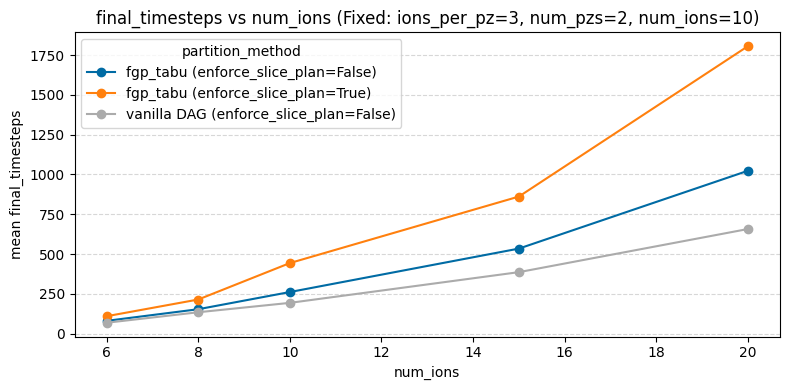

plotting with params {'ions_per_pz': 3, 'num_pzs': 2, 'num_ions': 10} over grid_size
Filtered to 3 runs with fixed params: {'ions_per_pz': 3, 'num_pzs': 2, 'num_ions': 10}
Saved: ../outputs/plots/final_timesteps_by_grid_size_ions_per_pz_3_num_pzs_2_num_ions_10.png
Saved: ../outputs/plots/final_timesteps_by_grid_size_ions_per_pz_3_num_pzs_2_num_ions_10.png


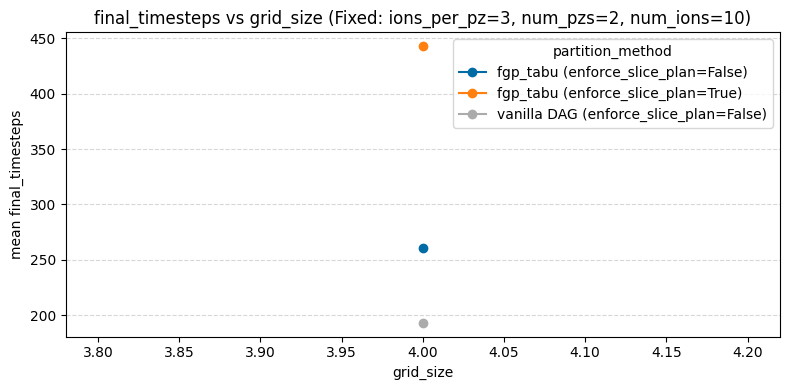

plotting with params {'ions_per_pz': 3, 'num_ions': 10} over num_pzs
Filtered to 9 runs with fixed params: {'ions_per_pz': 3, 'num_pzs': 2, 'num_ions': 10}
Saved: ../outputs/plots/final_timesteps_by_num_pzs_ions_per_pz_3_num_pzs_2_num_ions_10.png
Saved: ../outputs/plots/final_timesteps_by_num_pzs_ions_per_pz_3_num_pzs_2_num_ions_10.png


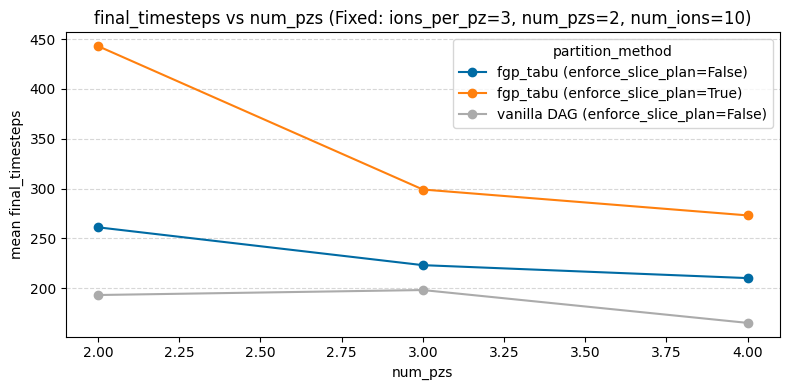


### Efficiency Analysis: final_timesteps * cpu_time_seconds
Higher values indicate better efficiency (more timesteps per second of compute)

plotting efficiency over num_ions with fixed params: {'ions_per_pz': 3, 'num_pzs': 2}
Filtered to 15 runs
Saved: ../outputs/plots/efficiency_by_num_ions_ions_per_pz_3_num_pzs_2_num_ions_10.png
Saved: ../outputs/plots/efficiency_by_num_ions_ions_per_pz_3_num_pzs_2_num_ions_10.png


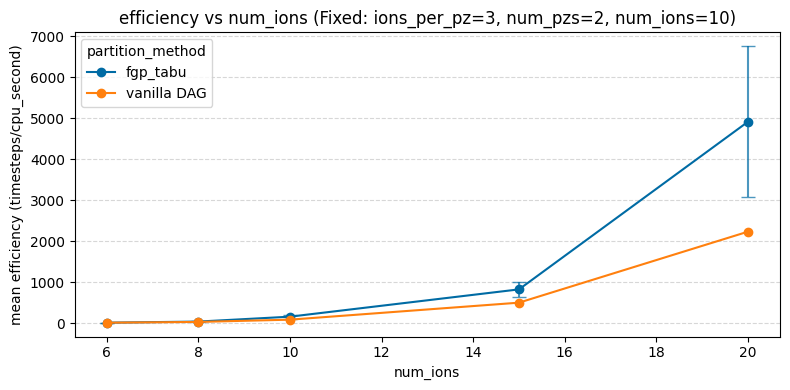


plotting efficiency over grid_size with fixed params: {'ions_per_pz': 3, 'num_pzs': 2, 'num_ions': 10}
Filtered to 3 runs
Saved: ../outputs/plots/efficiency_by_grid_size_ions_per_pz_3_num_pzs_2_num_ions_10.png
Saved: ../outputs/plots/efficiency_by_grid_size_ions_per_pz_3_num_pzs_2_num_ions_10.png


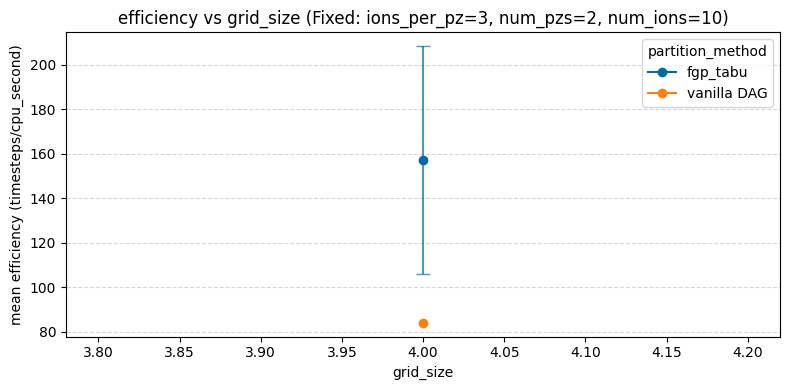


plotting efficiency over num_pzs with fixed params: {'ions_per_pz': 3, 'num_ions': 10}
Filtered to 9 runs
Saved: ../outputs/plots/efficiency_by_num_pzs_ions_per_pz_3_num_pzs_2_num_ions_10.png
Saved: ../outputs/plots/efficiency_by_num_pzs_ions_per_pz_3_num_pzs_2_num_ions_10.png


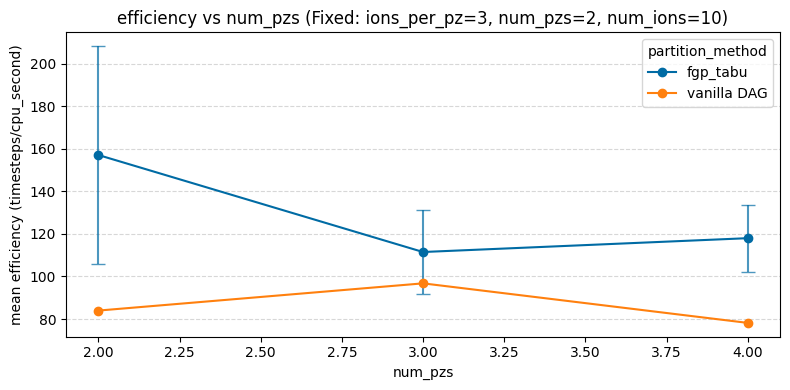

### cpu_time_seconds (ions_per_pz=3, num_pzs=2, num_ions=10)
plotting with params {'ions_per_pz': 3, 'num_pzs': 2} over num_ions
Filtered to 15 runs with fixed params: {'ions_per_pz': 3, 'num_pzs': 2, 'num_ions': 10}
Saved: ../outputs/plots/cpu_time_seconds_by_num_ions_ions_per_pz_3_num_pzs_2_num_ions_10.png


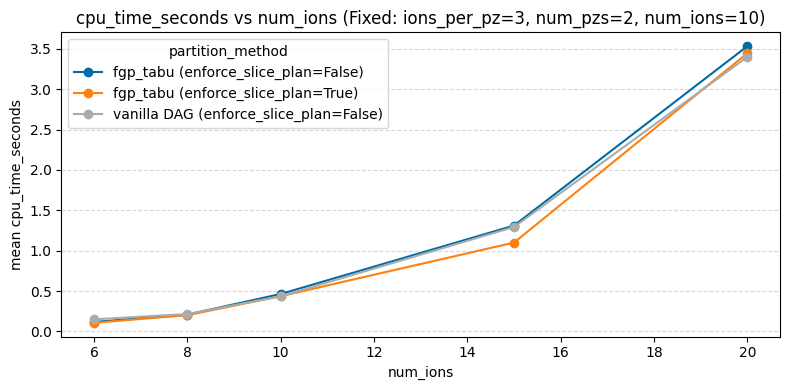

plotting with params {'ions_per_pz': 3, 'num_pzs': 2, 'num_ions': 10} over grid_size
Filtered to 3 runs with fixed params: {'ions_per_pz': 3, 'num_pzs': 2, 'num_ions': 10}
Saved: ../outputs/plots/cpu_time_seconds_by_grid_size_ions_per_pz_3_num_pzs_2_num_ions_10.png


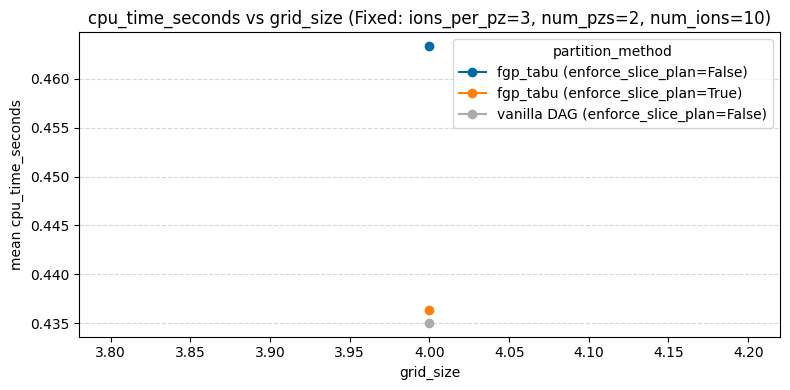

plotting with params {'ions_per_pz': 3, 'num_ions': 10} over num_pzs
Filtered to 9 runs with fixed params: {'ions_per_pz': 3, 'num_pzs': 2, 'num_ions': 10}
Saved: ../outputs/plots/cpu_time_seconds_by_num_pzs_ions_per_pz_3_num_pzs_2_num_ions_10.png
Saved: ../outputs/plots/cpu_time_seconds_by_num_pzs_ions_per_pz_3_num_pzs_2_num_ions_10.png


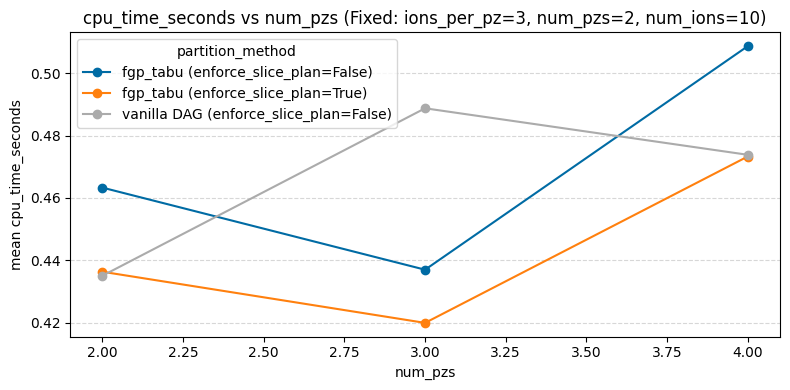


### Efficiency Analysis: final_timesteps * cpu_time_seconds
Higher values indicate better efficiency (more timesteps per second of compute)

plotting efficiency over num_ions with fixed params: {'ions_per_pz': 3, 'num_pzs': 2}
Filtered to 15 runs
Saved: ../outputs/plots/efficiency_by_num_ions_ions_per_pz_3_num_pzs_2_num_ions_10.png
Saved: ../outputs/plots/efficiency_by_num_ions_ions_per_pz_3_num_pzs_2_num_ions_10.png


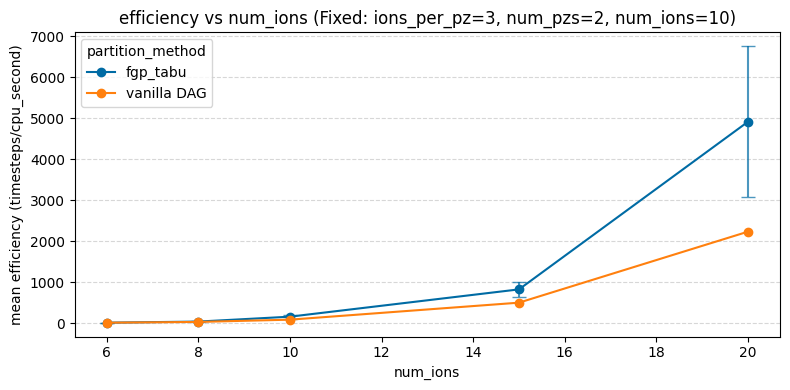


plotting efficiency over grid_size with fixed params: {'ions_per_pz': 3, 'num_pzs': 2, 'num_ions': 10}
Filtered to 3 runs
Saved: ../outputs/plots/efficiency_by_grid_size_ions_per_pz_3_num_pzs_2_num_ions_10.png
Saved: ../outputs/plots/efficiency_by_grid_size_ions_per_pz_3_num_pzs_2_num_ions_10.png


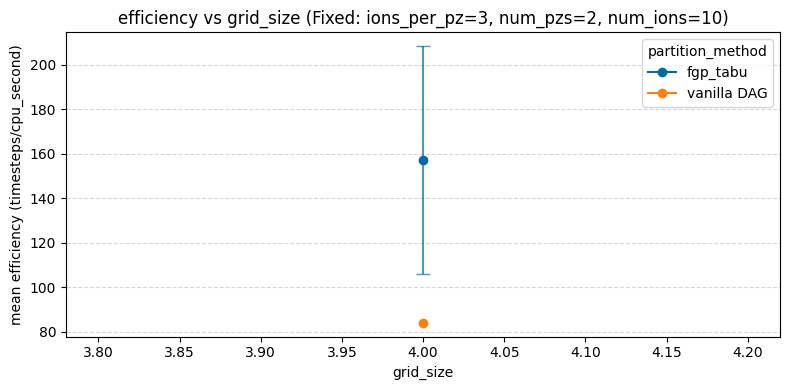


plotting efficiency over num_pzs with fixed params: {'ions_per_pz': 3, 'num_ions': 10}
Filtered to 9 runs
Saved: ../outputs/plots/efficiency_by_num_pzs_ions_per_pz_3_num_pzs_2_num_ions_10.png
Saved: ../outputs/plots/efficiency_by_num_pzs_ions_per_pz_3_num_pzs_2_num_ions_10.png


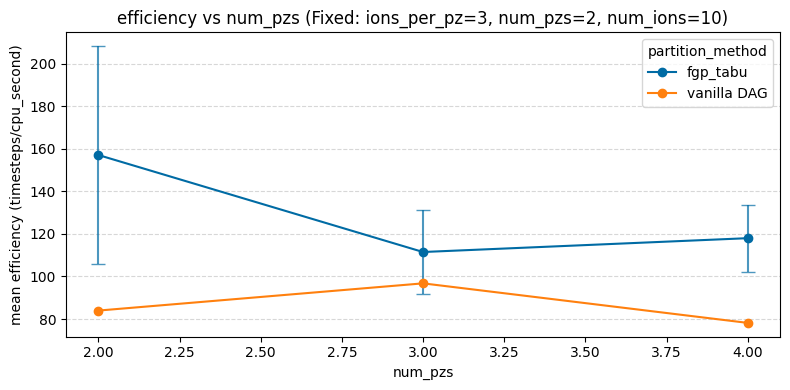

In [182]:
parameters_to_sweep = ["num_ions", "grid_size", "num_pzs"] #, "algo_lookahead_weight_factor", "algo_balance_penalty"]
#parameters_to_sweep = ["num_ions", "grid_size", "num_pzs", "algo_sigma", "algo_balance_penalty"]


# Define fixed parameters for filtering
fixed_params = {"ions_per_pz": 3, "num_pzs": 2, "num_ions": 10}  # Example: fix ions per processing zone to 2
#fixed_params = {"algo_sigma" : 1.88, "algo_balance_penalty": 0.19, "ions_per_pz": 2, "num_pzs": 3, "num_ions": 15}
#fixed_params = {"algo_sigma" : 1.88, "algo_balance_penalty": 0.19, "num_ions": 10, "num_pzs": 2, "ions_per_pz": 2, "grid_size": 3}
#fixed_params = {}

secondary_group = "enforce_slice_plan"


# Create filtered dataset

# Create suffix for filenames and titles
if fixed_params:
    param_suffix = "_".join(f"{key}_{value}" for key, value in fixed_params.items())
    title_suffix = ", ".join(f"{key}={value}" for key, value in fixed_params.items())
else:
    param_suffix = "all"
    title_suffix = "all configurations"

for metric in ["final_timesteps", "cpu_time_seconds"]:
    print(f"### {metric} ({title_suffix})")
    for param in parameters_to_sweep:
        local_fixed_params = {k: v for k, v in fixed_params.items() if k != param}
        filtered_df = apply_filters(success_df, local_fixed_params)
        print(f"plotting with params {local_fixed_params} over {param}")
        print(f"Filtered to {len(filtered_df)} runs with fixed params: {fixed_params}")
        
        result = plot_metric_by_param(filtered_df, metric=metric,  varying_param=param, method_col="partition_method", secondary_group=secondary_group)
        if result is None:
            print("No data to plot for this configuration; skipping figure.")
            continue
        fig, ax = result
        # Update title to include fixed parameters
        current_title = ax.get_title()
        ax.set_title(f"{current_title} (Fixed: {title_suffix})")
        # Save with descriptive filename
        filename = f"../outputs/plots/{metric}_by_{param}_{param_suffix}.png"
        plt.savefig(filename)
        print(f"Saved: {filename}")


        plt.show()

    # Compute and plot efficiency metric (final_timesteps / cpu_time_seconds)
    print("\n### Efficiency Analysis: final_timesteps * cpu_time_seconds")
    print("Higher values indicate better efficiency (more timesteps per second of compute)")

    for param in parameters_to_sweep:
        local_fixed_params = {k: v for k, v in fixed_params.items() if k != param}
        filtered_df = apply_filters(success_df, local_fixed_params)
        
        if filtered_df.empty:
            print(f"No data for parameter {param} with filters {local_fixed_params}")
            continue
        
        # Add efficiency metric
        filtered_df = filtered_df.copy()
        filtered_df['efficiency'] = filtered_df['final_timesteps'] * filtered_df['cpu_time_seconds']
        
        print(f"\nplotting efficiency over {param} with fixed params: {local_fixed_params}")
        print(f"Filtered to {len(filtered_df)} runs")
        
        result = plot_metric_by_param(filtered_df, metric="efficiency", varying_param=param, method_col="partition_method")
        if result is None:
            print("No data to plot for this configuration; skipping figure.")
            continue
        
        fig, ax = result
        current_title = ax.get_title()
        ax.set_title(f"{current_title} (Fixed: {title_suffix})")
        ax.set_ylabel("mean efficiency (timesteps/cpu_second)")
        
        # Save with descriptive filename
        filename = f"../outputs/plots/efficiency_by_{param}_{param_suffix}.png"
        plt.savefig(filename)
        print(f"Saved: {filename}")
        plt.show()

### Optional: compare full partition variants

Use the `partition_variant` column when you want to distinguish between different parameterizations of the same algorithm (for example different `num_clusters` values of `fgp_roee`).


### final_timesteps (partition variants)


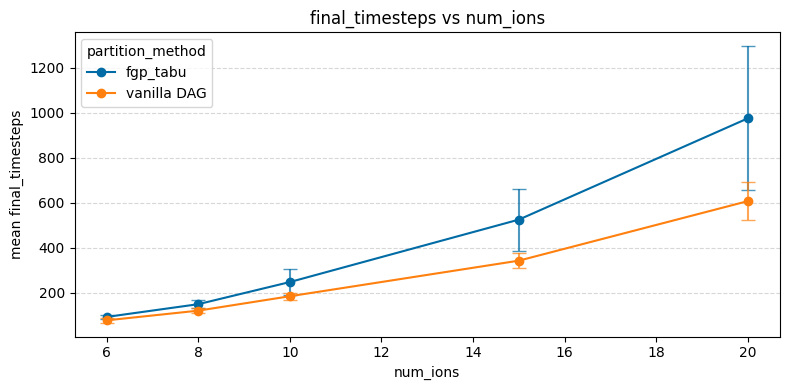

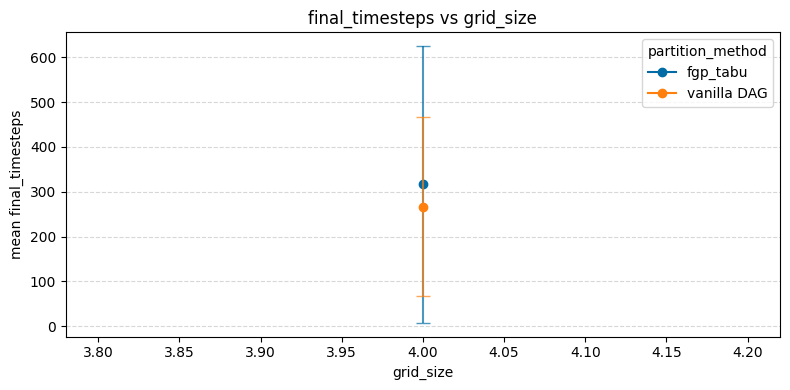

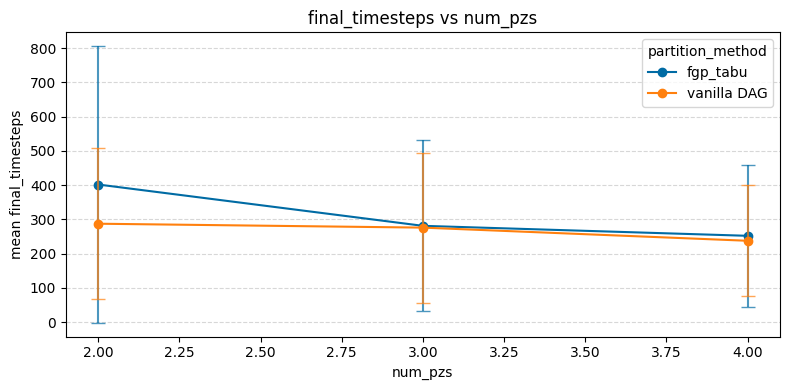

### cpu_time_seconds (partition variants)


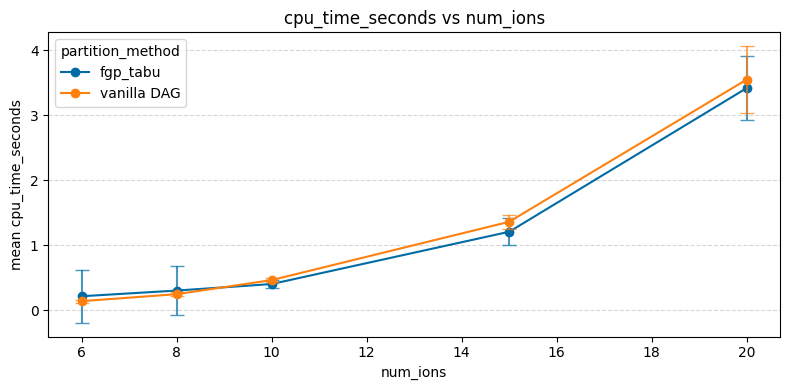

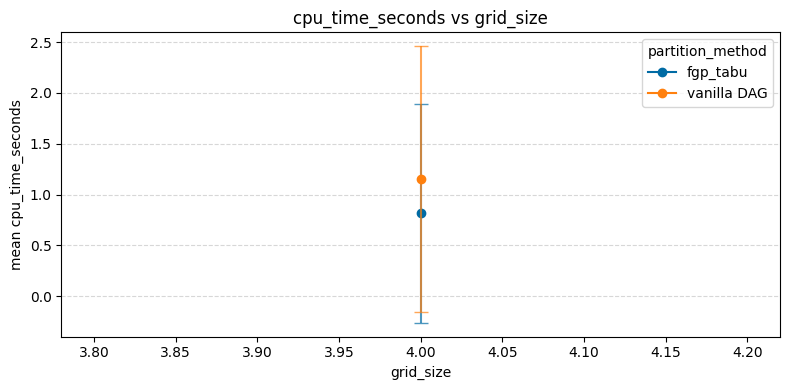

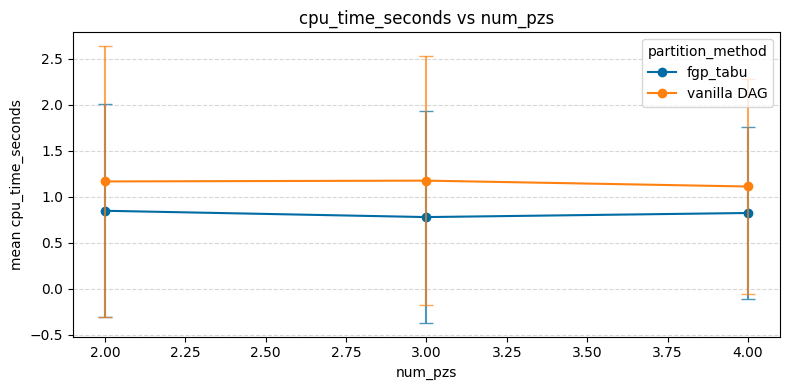

In [173]:
for metric in ("final_timesteps", "cpu_time_seconds"):
    print(f"### {metric} (partition variants)")
    for param in parameters_to_sweep:
        fig, _ = plot_metric_by_param(success_df, metric=metric, varying_param=param)
        plt.show()


## Relative improvements vs. the no-partitioning baseline

The helper below computes per-configuration deltas with respect to the baseline method (default: `none`). This is useful when you want to quantify how many timesteps or how much CPU time a strategy saves relative to running without partitioning.


In [166]:
def compute_relative_to_baseline(
    df: pd.DataFrame,
    metric: str,
    baseline_method: str = "none",
    method_col: str = "partition_method",
) -> pd.DataFrame:
    keys = [key for key in COMPARISON_KEYS if key in df.columns]
    baseline = (
        df[df[method_col] == baseline_method][keys + [metric]]
        .rename(columns={metric: f"{metric}_baseline"})
    )
    merged = df.merge(baseline, on=keys, how="left")
    merged = merged[merged[f"{metric}_baseline"].notna()].copy()
    merged[f"{metric}_delta"] = merged[metric] - merged[f"{metric}_baseline"]
    merged[f"{metric}_pct_change"] = merged[f"{metric}_delta"] / merged[f"{metric}_baseline"] * 100
    return merged

baseline_comparison_df = compute_relative_to_baseline(success_df, metric="final_timesteps")
baseline_comparison_df.head()


,run_name,algo_balance_penalty,algo_sigma,cpu_time_seconds,enforce_slice_plan,final_timesteps,grid_size,ions_per_pz,mz_trap_size,num_ions,num_pzs,success,use_dag,partition_method,partition_variant,partition_params,source_file,total_ions,grid_label,error_message,final_timesteps_baseline,final_timesteps_delta,final_timesteps_pct_change
74,run_0090,NaN,NaN,0.149388,False,68.0,4,3,1,6,2,True,True,none,none,{},outputs/simulation_results_generated.h5,6,4x4,NaN,68.0,0.0,0.000000
75,run_0090,NaN,NaN,0.149388,False,68.0,4,3,1,6,2,True,True,none,none,{},outputs/simulation_results_generated.h5,6,4x4,NaN,134.0,-66.0,-49.253731
76,run_0090,NaN,NaN,0.149388,False,68.0,4,3,1,6,2,True,True,none,none,{},outputs/simulation_results_generated.h5,6,4x4,NaN,193.0,-125.0,-64.766839
77,run_0090,NaN,NaN,0.149388,False,68.0,4,3,1,6,2,True,True,none,none,{},outputs/simulation_results_generated.h5,6,4x4,NaN,386.0,-318.0,-82.383420
78,run_0090,NaN,NaN,0.149388,False,68.0,4,3,1,6,2,True,True,none,none,{},outputs/simulation_results_generated.h5,6,4x4,NaN,657.0,-589.0,-89.649924


In [167]:
non_baseline = baseline_comparison_df[baseline_comparison_df["partition_method"] != "none"].copy()
_ = plot_metric_by_param(
    non_baseline,
    metric="final_timesteps_pct_change",
    varying_param="grid_size",
    method_col="partition_variant",
    filters={"use_dag": True},
)
plt.show()


### Next steps

- Adjust the `filters` dictionary within `plot_metric_by_param` to focus on specific traps, DAG settings, or slice-plan policies.
- Duplicate the plotting cells and switch the metric to `cpu_time_seconds_pct_change` after recomputing `baseline_comparison_df` for CPU time.
- Export any figure via `fig.savefig(...)` inside the plotting loops if you need artifacts for presentations or papers.
